Analisis Sentimen Ujaran Kebencian di Twitter dengan Pendekatan Regresi Logistik dan Naive Bayes Multinomial
(Detect hate speech (racist/sexist) in tweets.)

Yopi Julia Nurriski, Triani Femilia Agustina

**Importing the required libraries:**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from wordcloud import WordCloud,STOPWORDS
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.pipeline import make_pipeline

import warnings
warnings.filterwarnings("ignore")

**Loading the Data Set**

In [ ]:
dataset  = pd.read_csv('/content/drive/MyDrive/Semester 4/AI/train_tweets.csv')

**Memeriksa 5 baris pertama dari dataset train dan test:**

In [ ]:
dataset.head(5)

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


**Meneliti informasi dari dataset:**

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


Exploratory Data Analysis
**Memeriksa bentuk (jumlah baris dan kolom) dataset :**

In [ ]:
dataset.shape

(31962, 3)

**Memeriksa nilai yang hilang (NaN) dalam kolom 'tweet' pada dataset train:**

In [ ]:
dataset['tweet'].isna().sum()

0

**Mendefinisikan fungsi vectorization untuk melakukan vectorization pada data teks:**

Fungsi ini menggunakan CountVectorizer untuk mengubah koleksi dokumen teks menjadi matriks token frekuensi. Matriks frekuensi tersebut kemudian dijumlahkan untuk setiap kata, dan hasilnya disimpan dalam dataframe.

In [ ]:
def vectorization(table):
    #CountVectorizer will convert a collection of text documents to a matrix of token counts
    #Produces a sparse representation of the counts
    #Initialize
    vector = CountVectorizer()
    #We fit and transform the vector created
    frequency_matrix = vector.fit_transform(table.tweet)
    #Sum all the frequencies for each word
    sum_frequencies = np.sum(frequency_matrix, axis=0)
    #Now we use squeeze to remove single-dimensional entries from the shape of an array that we got from applying np.asarray to
    #the sum of frequencies.
    frequency = np.squeeze(np.asarray(sum_frequencies))
    #Now we get into a dataframe all the frequencies and the words that they correspond to
    frequency_df = pd.DataFrame([frequency], columns=vector.get_feature_names_out()).transpose()
    return frequency_df

**Fungsi drop_features untuk menghapus fitur yang tidak diinginkan:**
Fungsi ini digunakan untuk menghapus fitur-fitur yang tidak diinginkan dari dataset dengan memanggil fungsi drop pada objek DataFrame.

In [ ]:
#function to drop unwanted features

def drop_features(features,data):
    data.drop(features,inplace=True,axis=1)

**Data Cleaning**

In [ ]:
import re
def process_tweet(tweet):
    return " ".join(re.sub("(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])", " ",tweet.lower()).split())

In [ ]:
dataset['processed_tweets'] = dataset['tweet'].apply(process_tweet)

In [ ]:
dataset.head(5)

,id,label,tweet,processed_tweets
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so selfi...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for lyft credit i can t use cause they ...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,model i love u take with u all the time in ur
4,5,0,factsguide: society now #motivation,factsguide society now motivation


In [ ]:
data = dataset.drop(columns = ['id', 'label', 'tweet'])

In [ ]:
data

,processed_tweets
0,when a father is dysfunctional and is so selfi...
1,thanks for lyft credit i can t use cause they ...
2,bihday your majesty
3,model i love u take with u all the time in ur
4,factsguide society now motivation
...,...
31957,ate isz that youuu
31958,to see nina turner on the airwaves trying to w...
31959,listening to sad songs on a monday morning otw...
31960,sikh temple vandalised in in calgary wso conde...


Sentiment Analysis

Digunakan fungsi-fungsi yang menggunakan library TextBlob dalam bahasa Python. TextBlob adalah library yang digunakan untuk pemrosesan teks dan analisis sentimen.

Fungsi getSubjectivity(tweet) digunakan untuk menghitung subjektivitas dari sebuah teks tweet. Subjektivitas adalah ukuran sejauh mana teks tersebut bersifat subjektif atau objektif. Fungsi ini menggunakan metode sentiment.subjectivity dari objek TextBlob untuk menghitung subjektivitas teks.

Fungsi getPolarity(tweet) digunakan untuk menghitung polaritas dari sebuah teks tweet. Polaritas adalah ukuran sejauh mana teks tersebut bersifat positif, negatif, atau netral. Fungsi ini menggunakan metode sentiment.polarity dari objek TextBlob untuk menghitung polaritas teks.

Fungsi getAnalysis(score) digunakan untuk mengembalikan klasifikasi sentimen berdasarkan skor yang diberikan. Jika skor adalah 0, maka hasilnya adalah 'Netral'. Jika skor kurang dari 0, maka hasilnya adalah 'Negatif'. Jika skor lebih dari 0, maka hasilnya adalah 'Positif'. Fungsi ini digunakan untuk mengklasifikasikan sentimen berdasarkan polaritas yang diperoleh.


In [ ]:
from textblob import TextBlob
def getSubjectivity(processed_tweets) :
    return TextBlob(processed_tweets).sentiment.subjectivity
def getPolarity(processed_tweets) :
    return TextBlob(processed_tweets).sentiment.polarity
def getAnalysis(score) :
    return 'Neutral' if (score == 0) else ('Negative' if (score < 0) else 'Positive')

Pada baris pertama, train['Subjectivity'] = train['tweet'].apply(getSubjectivity), fungsi getSubjectivity() diterapkan pada kolom 'tweet' dari DataFrame train. Hasilnya kemudian disimpan dalam kolom baru bernama 'Subjectivity', yang akan berisi nilai subjektivitas dari masing-masing teks tweet.

Pada baris kedua, train['Polarity'] = train['tweet'].apply(getPolarity), fungsi getPolarity() diterapkan pada kolom 'tweet' dari DataFrame train. Hasilnya kemudian disimpan dalam kolom baru bernama 'Polarity', yang akan berisi nilai polaritas dari masing-masing teks tweet.

Pada baris ketiga, train['Analysis'] = train['Polarity'].apply(getAnalysis), fungsi getAnalysis() diterapkan pada kolom 'Polarity' dari DataFrame train. Hasilnya kemudian disimpan dalam kolom baru bernama 'Analysis', yang akan berisi hasil analisis sentimen (Netral, Negatif, atau Positif) berdasarkan nilai polaritas dari masing-masing teks tweet.

Dengan demikian, DataFrame train akan memiliki tiga kolom baru: 'Subjectivity', 'Polarity', dan 'Analysis', yang masing-masing berisi nilai subjektivitas, polaritas, dan hasil analisis sentimen dari teks tweet.

In [ ]:
data['Subjectivity'] = data['processed_tweets'].apply(getSubjectivity)
data['Polarity'] = data['processed_tweets'].apply(getPolarity)
data['Analysis'] = data['Polarity'].apply(getAnalysis)

data

,processed_tweets,Subjectivity,Polarity,Analysis
0,when a father is dysfunctional and is so selfi...,1.0,-0.5,Negative
1,thanks for lyft credit i can t use cause they ...,0.2,0.2,Positive
2,bihday your majesty,0.0,0.0,Neutral
3,model i love u take with u all the time in ur,0.6,0.5,Positive
4,factsguide society now motivation,0.0,0.0,Neutral
...,...,...,...,...
31957,ate isz that youuu,0.0,0.0,Neutral
31958,to see nina turner on the airwaves trying to w...,0.5,0.4,Positive
31959,listening to sad songs on a monday morning otw...,1.0,-0.5,Negative
31960,sikh temple vandalised in in calgary wso conde...,0.0,0.0,Neutral


In [ ]:
# Menghitung jumlah tweet berdasarkan hasil analisis
total_neutral = len(data[data['Analysis'] == 'Neutral'])
total_positive = len(data[data['Analysis'] == 'Positive'])
total_negative = len(data[data['Analysis'] == 'Negative'])

# Menampilkan jumlah tweet berdasarkan hasil analisis
print("Total Tweet:")
print("Netral:", total_neutral)
print("Positif:", total_positive)
print("Negatif:", total_negative)

Total Tweet:
Netral: 11149
Positif: 16118
Negatif: 4695


In [ ]:
def show_pie(Analysis, data, legend_title) :
    fig, ax = plt.subplots(figsize=(8, 10), subplot_kw=dict(aspect='equal'))

    labels = [x.split()[-1] for x in Analysis]

    def func(pct, allvals):
        absolute = int(pct/100.*np.sum(allvals))
        return "{:.1f}% ({:d})".format(pct, absolute)

    wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct, data),
                                      textprops=dict(color="w"))

    ax.legend(wedges, labels,
              title= legend_title,
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

    plt.setp(autotexts, size=10, weight="bold")
    plt.show()

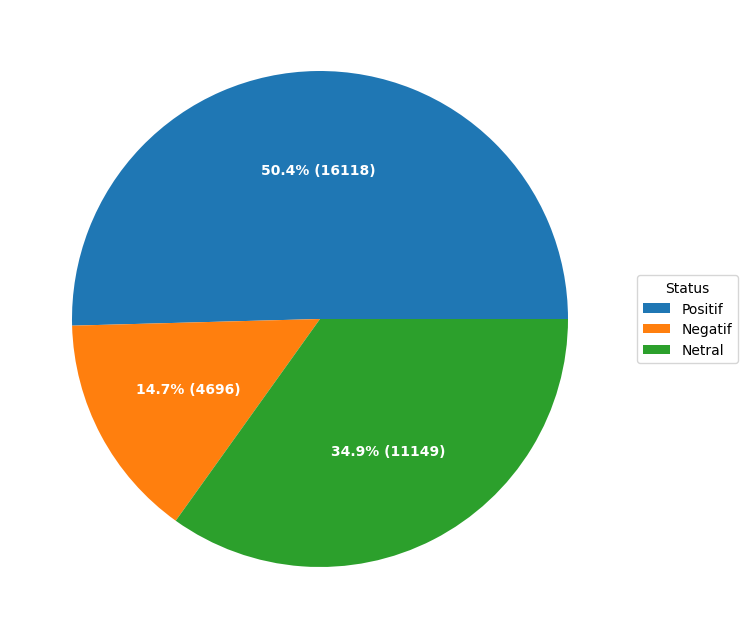

In [ ]:
label = ['Positif', 'Negatif', 'Netral']
count_data = [total_positive+1, total_negative+1, total_neutral]

show_pie(label, count_data, "Status")

Normal Tweets

Normal words


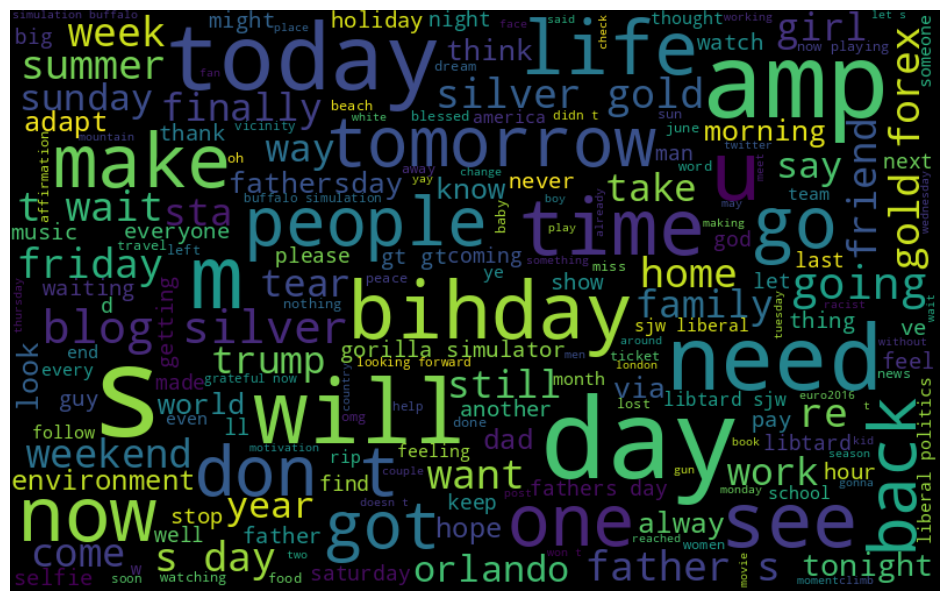

In [ ]:
normal_words = ' '.join([word for word in data['processed_tweets'][data['Analysis'] == 'Neutral']])
wordcloud = WordCloud(width = 800, height = 500, max_font_size = 110).generate(normal_words)
print('Normal words')
plt.figure(figsize= (12,8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Positif Tweets

Positif words


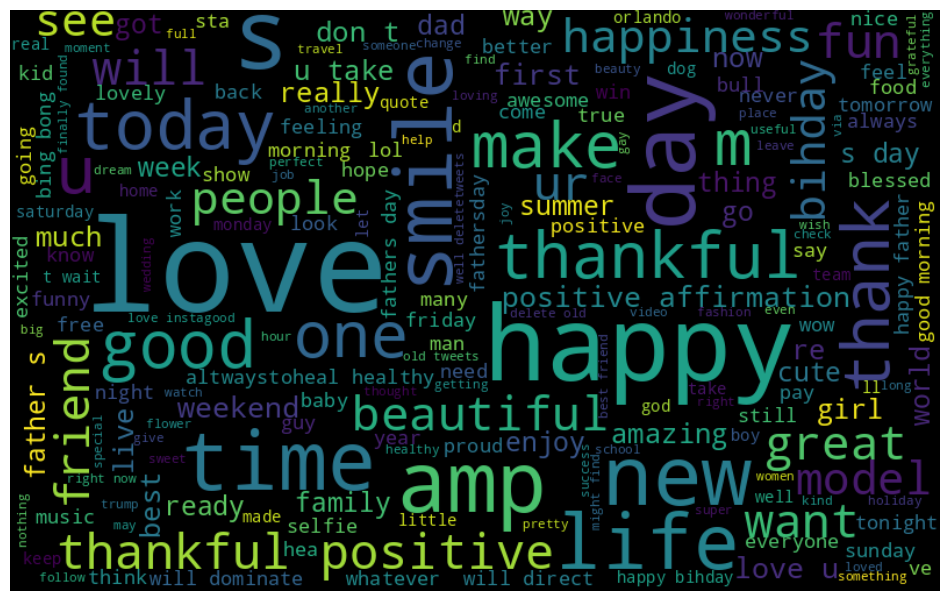

In [ ]:
positif_words = ' '.join([word for word in data['processed_tweets'][data['Analysis'] == 'Positive']])
wordcloud = WordCloud(width = 800, height = 500, max_font_size = 110).generate(positif_words)
print('Positif words')
plt.figure(figsize= (12,8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Negatif Tweets

Negative words


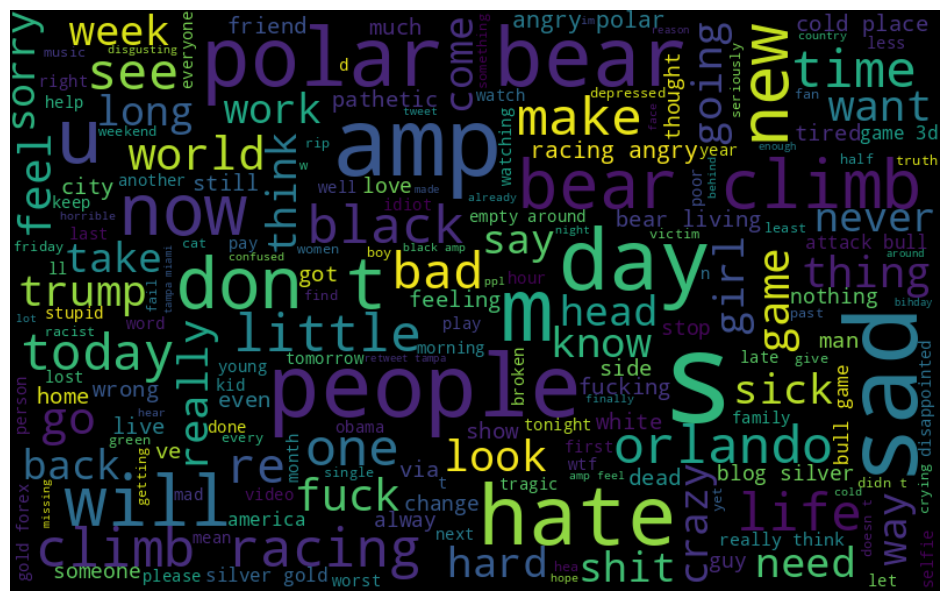

In [ ]:
negative_words = ' '.join([word for word in data['processed_tweets'][data['Analysis'] == 'Negative']])
wordcloud = WordCloud(width = 800, height = 500, max_font_size = 110).generate(negative_words)
print('Negative words')
plt.figure(figsize= (12,8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   processed_tweets  31962 non-null  object 
 1   Subjectivity      31962 non-null  float64
 2   Polarity          31962 non-null  float64
 3   Analysis          31962 non-null  object 
dtypes: float64(2), object(2)
memory usage: 998.9+ KB


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data["processed_tweets"], data["Analysis"], test_size = 0.2, random_state = 42)

In [ ]:
x_train

12110    because i ve been paying attention for the pas...
14081    raft building at salford quays as pa of the gm...
1829     friday gdegblog friday selfie beard gayguy gay...
2769                             fashion it is a true fact
31818    so to share the simple elegant businesscards i...
                               ...                        
29802    waltdisneyreso should be ashamed of themselves...
5390     invited over for a catch up and i couldn t sto...
860      black professor makes assumptions about an ent...
15795    lgbtqhatetrumppay is total liberal trash its a...
23654    what makes people is relative we have our way ...
Name: processed_tweets, Length: 25569, dtype: object

In [ ]:
y_train

12110    Negative
14081    Positive
1829      Neutral
2769     Positive
31818    Positive
           ...   
29802     Neutral
5390     Positive
860      Negative
15795    Negative
23654     Neutral
Name: Analysis, Length: 25569, dtype: object

CountVectorizer


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
count_vect = CountVectorizer(stop_words='english')
transformer = TfidfTransformer(norm='l2',sublinear_tf=True)

In [ ]:
x_train_counts = count_vect.fit_transform(x_train)
x_train_tfidf = transformer.fit_transform(x_train_counts)


In [ ]:
print(x_train_counts.shape)
print(x_train_tfidf.shape)

(25569, 33735)
(25569, 33735)


In [ ]:
x_train_counts

<25569x33735 sparse matrix of type '<class 'numpy.int64'>'
	with 179258 stored elements in Compressed Sparse Row format>

In [ ]:
x_test_counts = count_vect.transform(x_test)
x_test_tfidf = transformer.transform(x_test_counts)

In [ ]:
print(x_test_counts.shape)
print(x_test_tfidf.shape)

(6393, 33735)
(6393, 33735)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Preprocessing and Feature Extraction
tfidf = TfidfVectorizer()

# Support Vector Machine
svm = SVC(kernel='linear')

# Pipeline
clf = Pipeline([('tfidf', tfidf), ('svm', svm)])

# Train the model
clf.fit(x_train,y_train)

# Testing the model
print('Accuracy:', clf.score(x_test, y_test))

Accuracy: 0.9358673549194432


In [ ]:
clf.score(x_test, y_test)

0.9358673549194432

Summary Metrics
Precision score: 0.9369
Recall score: 0.9359
Accuracy score: 0.9359
F1 score: 0.93482250


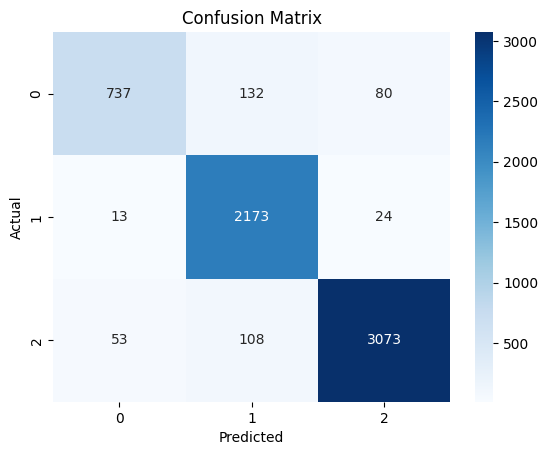

Classification Report:
               precision    recall  f1-score   support

    Negative       0.92      0.78      0.84       949
     Neutral       0.90      0.98      0.94      2210
    Positive       0.97      0.95      0.96      3234

    accuracy                           0.94      6393
   macro avg       0.93      0.90      0.91      6393
weighted avg       0.94      0.94      0.93      6393



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score, f1_score
import seaborn as sn

# Testing the model and print confusion matrix
y_pred = clf.predict(x_test)

comparePrecision=[]
compareRecall=[]
compareAccuracy=[]
compareF1=[]

print('Summary Metrics')
print('Precision score: {:.4f}'.format(precision_score(y_test, y_pred, average='weighted')))
comparePrecision.append(precision_score(y_test, y_pred, average='weighted'))
print('Recall score: {:.4f}'.format(recall_score(y_test, y_pred, average='weighted')))
compareRecall.append(recall_score(y_test, y_pred, average='weighted'))
print('Accuracy score: {:.4f}'.format(accuracy_score(y_test, y_pred)))
compareAccuracy.append(accuracy_score(y_test, y_pred))
print('F1 score: {:.8f}'.format(f1_score(y_test, y_pred, average='weighted')))
compareF1.append(f1_score(y_test, y_pred, average='weighted'))

plt.title("Confusion Matrix")
sn.heatmap(confusion_matrix(y_test,y_pred), annot=True, cmap="Blues",fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Print precision, recall, and f1-score
print('Classification Report:\n', classification_report(y_test, y_pred))

Summary Metrics:
Precision score: 0.9359218774899153
Recall score: 0.9369623025183795
Accuracy score: 0.9369623025183795
F1 score: 0.9362718311009468


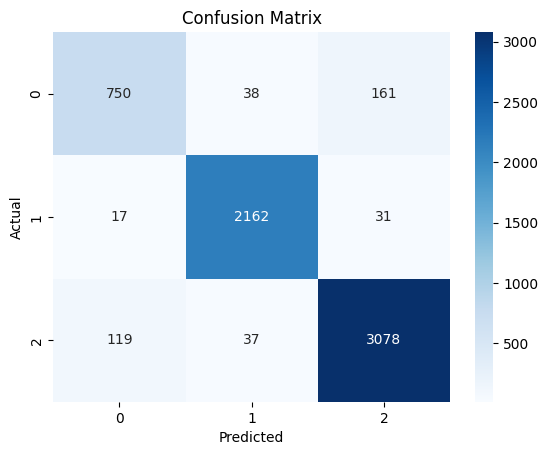

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.79      0.82       949
     Neutral       0.97      0.98      0.97      2210
    Positive       0.94      0.95      0.95      3234

    accuracy                           0.94      6393
   macro avg       0.92      0.91      0.91      6393
weighted avg       0.94      0.94      0.94      6393



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report, confusion_matrix

# Preprocessing and Feature Extraction
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

# Decision Tree Classifier
dt = DecisionTreeClassifier()

# Training the model
dt.fit(x_train_tfidf, y_train)

# Testing the model
y_pred = dt.predict(x_test_tfidf)

# Summary Metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Summary Metrics:")
print("Precision score:", precision)
print("Recall score:", recall)
print("Accuracy score:", accuracy)
print("F1 score:", f1)

# Confusion Matrix
plt.title("Confusion Matrix")
sn.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Summary Metrics:
Precision score: 0.9082564825153434
Recall score: 0.9022368215235413
Accuracy score: 0.9022368215235413
F1 score: 0.8970267286592151


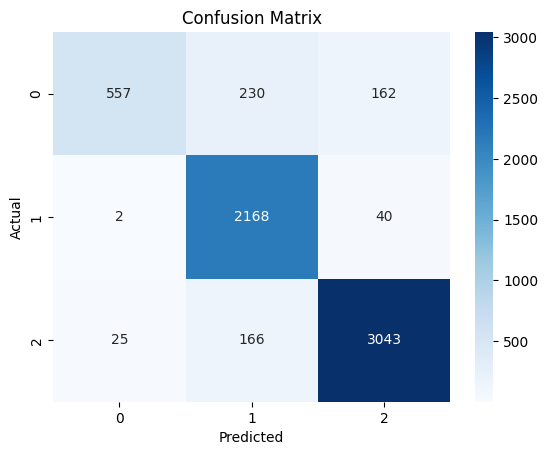

Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.59      0.73       949
     Neutral       0.85      0.98      0.91      2210
    Positive       0.94      0.94      0.94      3234

    accuracy                           0.90      6393
   macro avg       0.91      0.84      0.86      6393
weighted avg       0.91      0.90      0.90      6393



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sn

# Preprocessing and Feature Extraction
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

# Random Forest Classifier
rf = RandomForestClassifier()

# Training the model
rf.fit(x_train_tfidf, y_train)

# Testing the model
y_pred = rf.predict(x_test_tfidf)

# Summary Metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Summary Metrics:")
print("Precision score:", precision)
print("Recall score:", recall)
print("Accuracy score:", accuracy)
print("F1 score:", f1)

# Confusion Matrix
plt.title("Confusion Matrix")
sn.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


**Stacking 1**

Summary Metrics:
Precision score: 0.9606727328667026
Recall score: 0.9610511496949788
Accuracy score: 0.9610511496949788
F1 score: 0.9607420262376413


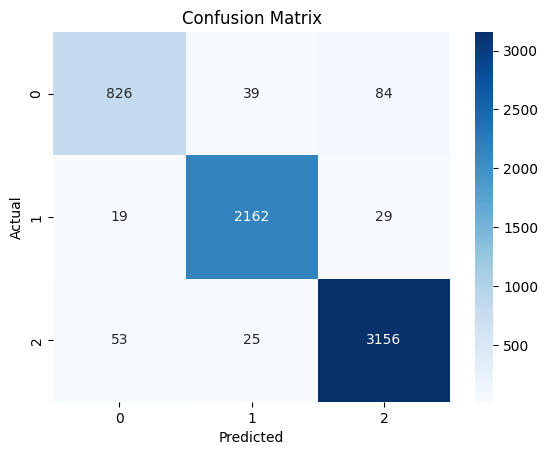

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.87      0.89       949
     Neutral       0.97      0.98      0.97      2210
    Positive       0.97      0.98      0.97      3234

    accuracy                           0.96      6393
   macro avg       0.95      0.94      0.95      6393
weighted avg       0.96      0.96      0.96      6393



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report, confusion_matrix

# Preprocessing and Feature Extraction
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

# Base models
svm = SVC(kernel='linear')
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

# Stacking ensemble model
estimators = [('svm', svm), ('dt', dt), ('rf', rf)]
stacking_model = StackingClassifier(estimators=estimators)

# Training the stacking model
stacking_model.fit(x_train_tfidf, y_train)

# Testing the stacking model
y_pred = stacking_model.predict(x_test_tfidf)

# Summary Metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Summary Metrics:")
print("Precision score:", precision)
print("Recall score:", recall)
print("Accuracy score:", accuracy)
print("F1 score:", f1)

# Confusion Matrix
plt.title("Confusion Matrix")
sn.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Akurasi 96,10 % dan F1-Score 96,07%